In [131]:
import sys

sys.path.append("../") # go to parent dir

import pandas as pd
import numpy as np
from custom_helpers_py.get_paths import get_out_folder_capitol_trades,get_out_folder_analysis
from custom_helpers_py.utilities import camel_to_snake_case
from os.path import join
from os import listdir
import math
import json
import matplotlib.pyplot as plt

RESULTS_FOLDER = "./res"

In [132]:
# politicians df
POLITICIAN_DATA_FOLDER_PATH = join(get_out_folder_capitol_trades(), "politician_data")
file_list = listdir(POLITICIAN_DATA_FOLDER_PATH)

politician_data_list = []
for file_name in file_list:
    file_path = join(POLITICIAN_DATA_FOLDER_PATH, file_name)
    with open(file_path, "r", encoding="utf-8") as in_file: 
        file_obj: dict = json.loads(in_file.read())
    
    fact_dict:dict = file_obj["factDict"]
    if fact_dict.get("trade"):
        fact_dict["trades"] = "1"
        del fact_dict["trade"] 

    if fact_dict.get("issuer"):
        fact_dict["issuers"] = "1"
        del fact_dict["issuer"]
    
    to_add = {
        "id": file_name.removesuffix(".json"),
        "fullName": file_obj.get("fullName"),
        **file_obj.get("officeInfo"),
        **file_obj.get("factDict"),
        "committeeList": file_obj.get("committeeList")
    }

    to_add["yearsActive"] = to_add["yearsActive"].replace('–', "-")
    politician_data_list.append(to_add)

politician_df = pd.DataFrame(politician_data_list)
politician_df.columns = [camel_to_snake_case(col) for col in politician_df.columns]


def convert_num_str(in_str: str):
    if "K" in in_str:
        in_str = in_str.removesuffix("K")
        return int(float(in_str) * 1_000)
    
    if "M" in in_str:
        in_str = in_str.removesuffix("M")
        return int(float(in_str) * 1_000_000)

    if "," in in_str:
        in_str = in_str.replace(",","")
    return int(in_str)

politician_df["volume"] = politician_df["volume"].apply(convert_num_str)
politician_df["trades"] = politician_df["trades"].apply(convert_num_str)
politician_df["issuers"] = politician_df["issuers"].apply(convert_num_str)

def get_year_active_started(in_str: str):
    return int(in_str.split(" - ")[0])

def get_year_active_ended(in_str: str):
    to_return =  in_str.split(" - ")[1]
    if to_return == "current":
        to_return = 2025
    return int(to_return)

politician_df["year_active_started"] = politician_df["years_active"].apply(get_year_active_started)
politician_df["year_active_ended"] = politician_df["years_active"].apply(get_year_active_ended)
    
politician_df

,id,full_name,party,chamber,state,trades,issuers,volume,last_traded,district,years_active,date_of_birth,age,committee_list,year_active_started,year_active_ended
0,A000055,Robert Aderholt,Republican,House,Alabama,2,2,16000,2022-12-05,4,1997 - 2025,1965-07-22,58,[Appropriations],1997,2025
1,A000148,Jake Auchincloss,Democrat,House,Massachusetts,1,1,33000,2022-03-22,4,2021 - 2025,1988-01-29,36,"[Transportation & Infrastructure, Strategic Co...",2021,2025
2,A000372,Rick Allen,Republican,House,Georgia,70,19,4050000,2024-01-17,12,2015 - 2025,1951-11-07,72,"[Education & Labor, Energy & Commerce]",2015,2025
3,A000378,Cindy Axne,Democrat,House,Iowa,75,20,600000,2022-12-23,3,2019 - current,1965-04-20,58,[],2019,2025
4,B000574,Earl Blumenauer,Democrat,House,Oregon,198,86,3630000,2024-02-15,3,1995 - 2025,1948-08-16,75,"[Budget, Ways & Means]",1995,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,W000809,Steve Womack,Republican,House,Arkansas,1,1,33000,2022-11-17,3,2011 - 2025,1957-02-18,67,[Appropriations],2011,2025
209,W000812,Ann Wagner,Republican,House,Missouri,28,28,6000000,2023-11-30,2,2013 - 2025,1962-09-13,61,"[Financial Services, Foreign Affairs]",2013,2025
210,W000823,Michael Waltz,Republican,House,Florida,2,1,65000,2021-06-16,6,2019 - 2025,1974-01-31,50,"[Intelligence, Armed Services, Foreign Affairs]",2019,2025
211,Y000062,John Yarmuth,Democrat,House,Kentucky,14,12,161000,2021-10-22,3,2007 - current,1947-11-04,76,[],2007,2025


In [133]:
# trades df
TRADES_DATA_FOLDER_PATH = join(get_out_folder_capitol_trades(), "trade_scrapes")
file_list = listdir(TRADES_DATA_FOLDER_PATH)

trade_data_list = []
for file_name in file_list:
    file_path = join(TRADES_DATA_FOLDER_PATH, file_name)
    with open(file_path, "r", encoding="utf-8") as in_file: 
        file_obj: dict = json.loads(in_file.read())
    
    data_list: list= file_obj["dataList"]
    for obj in data_list:
        # ticker is ticker symbol and location
        issuer_obj = obj["issuer"]
        issuer_obj["issuer_id"] = issuer_obj["id"]
        del issuer_obj["pageLink"]
        del issuer_obj["id"]
        
        published_date = obj["pubDate"]["value"] + " " + obj["pubDate"]["label"]
        tx_date = obj["txDate"]["value"] + " " + obj["txDate"]["label"]
        
        to_add = {
            "politician_name": obj["politician"]["fullName"],
            "politician_id": obj["politician"]["id"],
            **issuer_obj,
            "published_date": published_date,
            "tx_date": tx_date,
            "reporting_gap": obj["reportingGap"],
            "owner": obj["owner"],
            "tx_type": obj["txType"],
            "value": obj["value"].replace("–","-"),
            "price": obj["price"],
        }
        trade_data_list.append(to_add)

trade_df = pd.DataFrame(trade_data_list)
trade_df.columns = [camel_to_snake_case(col) for col in trade_df.columns]

# Separate tickers
def get_ticker_location(in_str:str):
    if ":" in in_str:
        return in_str.split(":")[1]
    return None

def fix_ticker(in_str:str):
    if in_str == "N/A":
        return None
    if ":" in in_str:
        return in_str.split(":")[0]
    return in_str

trade_df["ticker_location"] = trade_df["ticker"].apply(get_ticker_location)
trade_df["ticker"] = trade_df["ticker"].apply(fix_ticker)

# Fix published date
def fix_date(in_str: str):
    if "Today" in in_str:
        in_str = "22 Mar 2024"
    
    return pd.to_datetime(in_str)
    
trade_df["published_date"] = trade_df["published_date"].apply(fix_date) 
trade_df["tx_date"] = trade_df["tx_date"].apply(fix_date) 

# Fix reporting gap
def fix_reporting_gap(in_str: str):
    in_str = in_str.upper()
    in_str = in_str.removesuffix("DAY")
    in_str = in_str.removesuffix("DAYS")
    in_str = in_str.strip()
    return int(in_str)
trade_df["reporting_gap"] = trade_df["reporting_gap"].apply(fix_reporting_gap)

# Get value
def convert_value_to_number(in_str: str):
    if "K" in in_str:
        in_str = in_str.removesuffix("K")
        return int(in_str) * 1_000

    if "M" in in_str:
        in_str = in_str.removesuffix("M")
        return int(in_str) * 1_000_000
    
    return int(in_str)
        
def get_value_low(in_str: str):
    if not "-" in in_str:
        return 0
    
    to_return =  in_str.split("-")[0]
    return convert_value_to_number(to_return) + 1

def get_value_high(in_str: str):
    if not "-" in in_str:
        return 999
    
    to_return =  in_str.split("-")[1]
    return convert_value_to_number(to_return)

def get_value_avg(in_row: dict):
    value_low = in_row["value_low"]
    if not isinstance(value_low, int):
        return np.nan
    
    value_high = in_row["value_high"]
    return math.ceil((value_low + value_high) / 2)
    
trade_df["value_low"] = trade_df["value"].apply(get_value_low)
trade_df["value_high"] = trade_df["value"].apply(get_value_high)
trade_df["value_avg"] = trade_df.apply(get_value_avg, axis=1)

# Fix price
def fix_price(in_str: str):
    if in_str == "N/A":
        return np.nan
    
    in_str = in_str.replace(",", "")
    return float(in_str)
    
    
trade_df["price"] = trade_df["price"].apply(fix_price)

# Get units bought
def get_units(in_row: dict, val: str):
    price = in_row["price"]
    if pd.isna(price) or price == 0:
        return np.nan
    
    value = in_row["value_" + val]
    if pd.isna(value):
        return np.nan

    return math.ceil(value / price)
    
trade_df["units_low"] = trade_df.apply(lambda x: get_units(x, "low"), axis=1)
trade_df["units_high"] = trade_df.apply(lambda x: get_units(x, "high"), axis=1)
trade_df["units_avg"] = trade_df.apply(lambda x: get_units(x, "avg"), axis=1)

trade_df

,politician_name,politician_id,issuer_name,ticker,issuer_id,published_date,tx_date,reporting_gap,owner,tx_type,value,price,ticker_location,value_low,value_high,value_avg,units_low,units_high,units_avg
0,Dan Meuser,M001204,NVIDIA Corporation,NVDA,433770,2024-03-22,2024-02-20,30,Spouse,SELL,250K-500K,694.52,US,250001,500000,375001,360.0,720.0,540.0
1,Dan Meuser,M001204,NVIDIA Corporation,NVDA,433770,2024-03-22,2024-02-20,30,Child,SELL,15K-50K,694.52,US,15001,50000,32501,22.0,72.0,47.0
2,Dan Meuser,M001204,NVIDIA Corporation,NVDA,433770,2024-03-22,2024-02-20,30,Child,SELL,15K-50K,694.52,US,15001,50000,32501,22.0,72.0,47.0
3,Dan Meuser,M001204,US TREASURY BILLS,None,435544,2024-03-22,2024-02-23,27,Spouse,BUY,250K-500K,NaN,None,250001,500000,375001,NaN,NaN,NaN
4,Nancy Pelosi,P000197,FORGE INVESTMENTS LLC,None,2334676,2024-03-22,2024-03-04,17,Spouse,BUY,1M-5M,NaN,None,1000001,5000000,3000001,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37909,Hal Rogers,R000395,BRIDGE BUILDER LARGE CAP VALUE FUND,BBVLX,430218,2021-04-02,2021-03-25,7,Undisclosed,SELL,1K-15K,15.99,US,1001,15000,8001,63.0,939.0,501.0
37910,Hal Rogers,R000395,BRIDGE BUILDER SMALL MID CAP VALUE FUND,BBVSX,430221,2021-04-02,2021-03-25,7,Undisclosed,SELL,1K-15K,14.34,US,1001,15000,8001,70.0,1047.0,558.0
37911,Mark Green,G000590,American Airlines Group Inc,AAL,429663,2021-03-29,2021-03-24,4,Joint,BUY,1K-15K,21.81,US,1001,15000,8001,46.0,688.0,367.0
37912,Mark Green,G000590,United Airlines Holdings Inc,UAL,435462,2021-03-29,2021-03-24,4,Joint,BUY,1K-15K,53.83,US,1001,15000,8001,19.0,279.0,149.0


In [134]:
tmp_df = politician_df.copy(deep=True)
tmp_df.columns = ["politician_" + col for col in tmp_df.columns]
master_df = trade_df.merge(tmp_df, how="left", on="politician_id").drop(columns=["politician_name"])

MASTER_DF_FILE_PATH = join(RESULTS_FOLDER, "master_df.csv")
master_df.to_csv(MASTER_DF_FILE_PATH, index=False, encoding="utf-8")
master_df

,politician_id,issuer_name,ticker,issuer_id,published_date,tx_date,reporting_gap,owner,tx_type,value,...,politician_issuers,politician_volume,politician_last_traded,politician_district,politician_years_active,politician_date_of_birth,politician_age,politician_committee_list,politician_year_active_started,politician_year_active_ended
0,M001204,NVIDIA Corporation,NVDA,433770,2024-03-22,2024-02-20,30,Spouse,SELL,250K-500K,...,3,1650000,2024-02-23,9,2019 - 2025,1964-02-10,60,"[Financial Services, Small business]",2019,2025
1,M001204,NVIDIA Corporation,NVDA,433770,2024-03-22,2024-02-20,30,Child,SELL,15K-50K,...,3,1650000,2024-02-23,9,2019 - 2025,1964-02-10,60,"[Financial Services, Small business]",2019,2025
2,M001204,NVIDIA Corporation,NVDA,433770,2024-03-22,2024-02-20,30,Child,SELL,15K-50K,...,3,1650000,2024-02-23,9,2019 - 2025,1964-02-10,60,"[Financial Services, Small business]",2019,2025
3,M001204,US TREASURY BILLS,None,435544,2024-03-22,2024-02-23,27,Spouse,BUY,250K-500K,...,3,1650000,2024-02-23,9,2019 - 2025,1964-02-10,60,"[Financial Services, Small business]",2019,2025
4,P000197,FORGE INVESTMENTS LLC,None,2334676,2024-03-22,2024-03-04,17,Spouse,BUY,1M-5M,...,22,51740000,2024-02-21,11,1987 - 2025,1940-03-26,83,[],1987,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37909,R000395,BRIDGE BUILDER LARGE CAP VALUE FUND,BBVLX,430218,2021-04-02,2021-03-25,7,Undisclosed,SELL,1K-15K,...,20,313000,2023-11-03,5,1983 - 2025,1937-12-31,86,[Appropriations],1983,2025
37910,R000395,BRIDGE BUILDER SMALL MID CAP VALUE FUND,BBVSX,430221,2021-04-02,2021-03-25,7,Undisclosed,SELL,1K-15K,...,20,313000,2023-11-03,5,1983 - 2025,1937-12-31,86,[Appropriations],1983,2025
37911,G000590,American Airlines Group Inc,AAL,429663,2021-03-29,2021-03-24,4,Joint,BUY,1K-15K,...,35,62450000,2024-03-11,7,2019 - 2025,1964-11-08,59,"[Foreign Affairs, Homeland Security]",2019,2025
37912,G000590,United Airlines Holdings Inc,UAL,435462,2021-03-29,2021-03-24,4,Joint,BUY,1K-15K,...,35,62450000,2024-03-11,7,2019 - 2025,1964-11-08,59,"[Foreign Affairs, Homeland Security]",2019,2025


In [135]:
def display_num(num: int | float):
    scientific_notation="{:e}".format(num)
    return scientific_notation

    
def get_spend_df(in_master_df: pd.DataFrame):
    spend_df = in_master_df.groupby("politician_id").agg({
        "value_low": "sum",
        "value_high": "sum",
        "value_avg": "sum",
    }).rename_axis("politician_id").reset_index()


    tmp_df = in_master_df[["politician_id","politician_full_name"]]
    spend_df = tmp_df.merge(spend_df,on="politician_id", how="left")
    spend_df = spend_df.drop_duplicates(subset="politician_id")

    spend_df = spend_df.sort_values(by="value_avg", ascending=False).reset_index(drop=True)

    return spend_df

def get_spend_df_states(in_master_df: pd.DataFrame):
    spend_df = in_master_df.groupby("politician_state").agg({
        "value_low": "sum",
        "value_high": "sum",
        "value_avg": "sum",
    }).rename_axis("politician_state").reset_index()


    spend_df = spend_df.drop_duplicates(subset="politician_state")

    spend_df = spend_df.sort_values(by="value_avg", ascending=False).reset_index(drop=True)

    return spend_df

def print_spend_totals(in_spend_df:pd.DataFrame):
    low_total = in_spend_df["value_low"].sum()
    high_total = in_spend_df["value_high"].sum()
    avg_total = in_spend_df["value_avg"].sum()

    print("low total", display_num(low_total))
    print("high total", display_num(high_total))
    print("avg total", display_num(avg_total))



In [136]:
# How many did each congress person spend on stocks?
indiv_spend_df = get_spend_df(master_df)
indiv_spend_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,M001157,Michael McCaul,316083401,752095000,534091901
1,K000389,Ro Khanna,106613096,435395000,271011596
2,G000583,Josh Gottheimer,82886349,377475000,230181349
3,D000617,Suzan DelBene,55972199,192030000,124001199
4,S001217,Rick Scott,50353121,150245000,100299121
...,...,...,...,...,...
208,M001186,Peter Meijer,1001,15000,8001
209,T000476,Thom Tillis,1001,15000,8001
210,B001275,Larry Bucshon,1001,15000,8001
211,B001257,Gus Bilirakis,1001,15000,8001


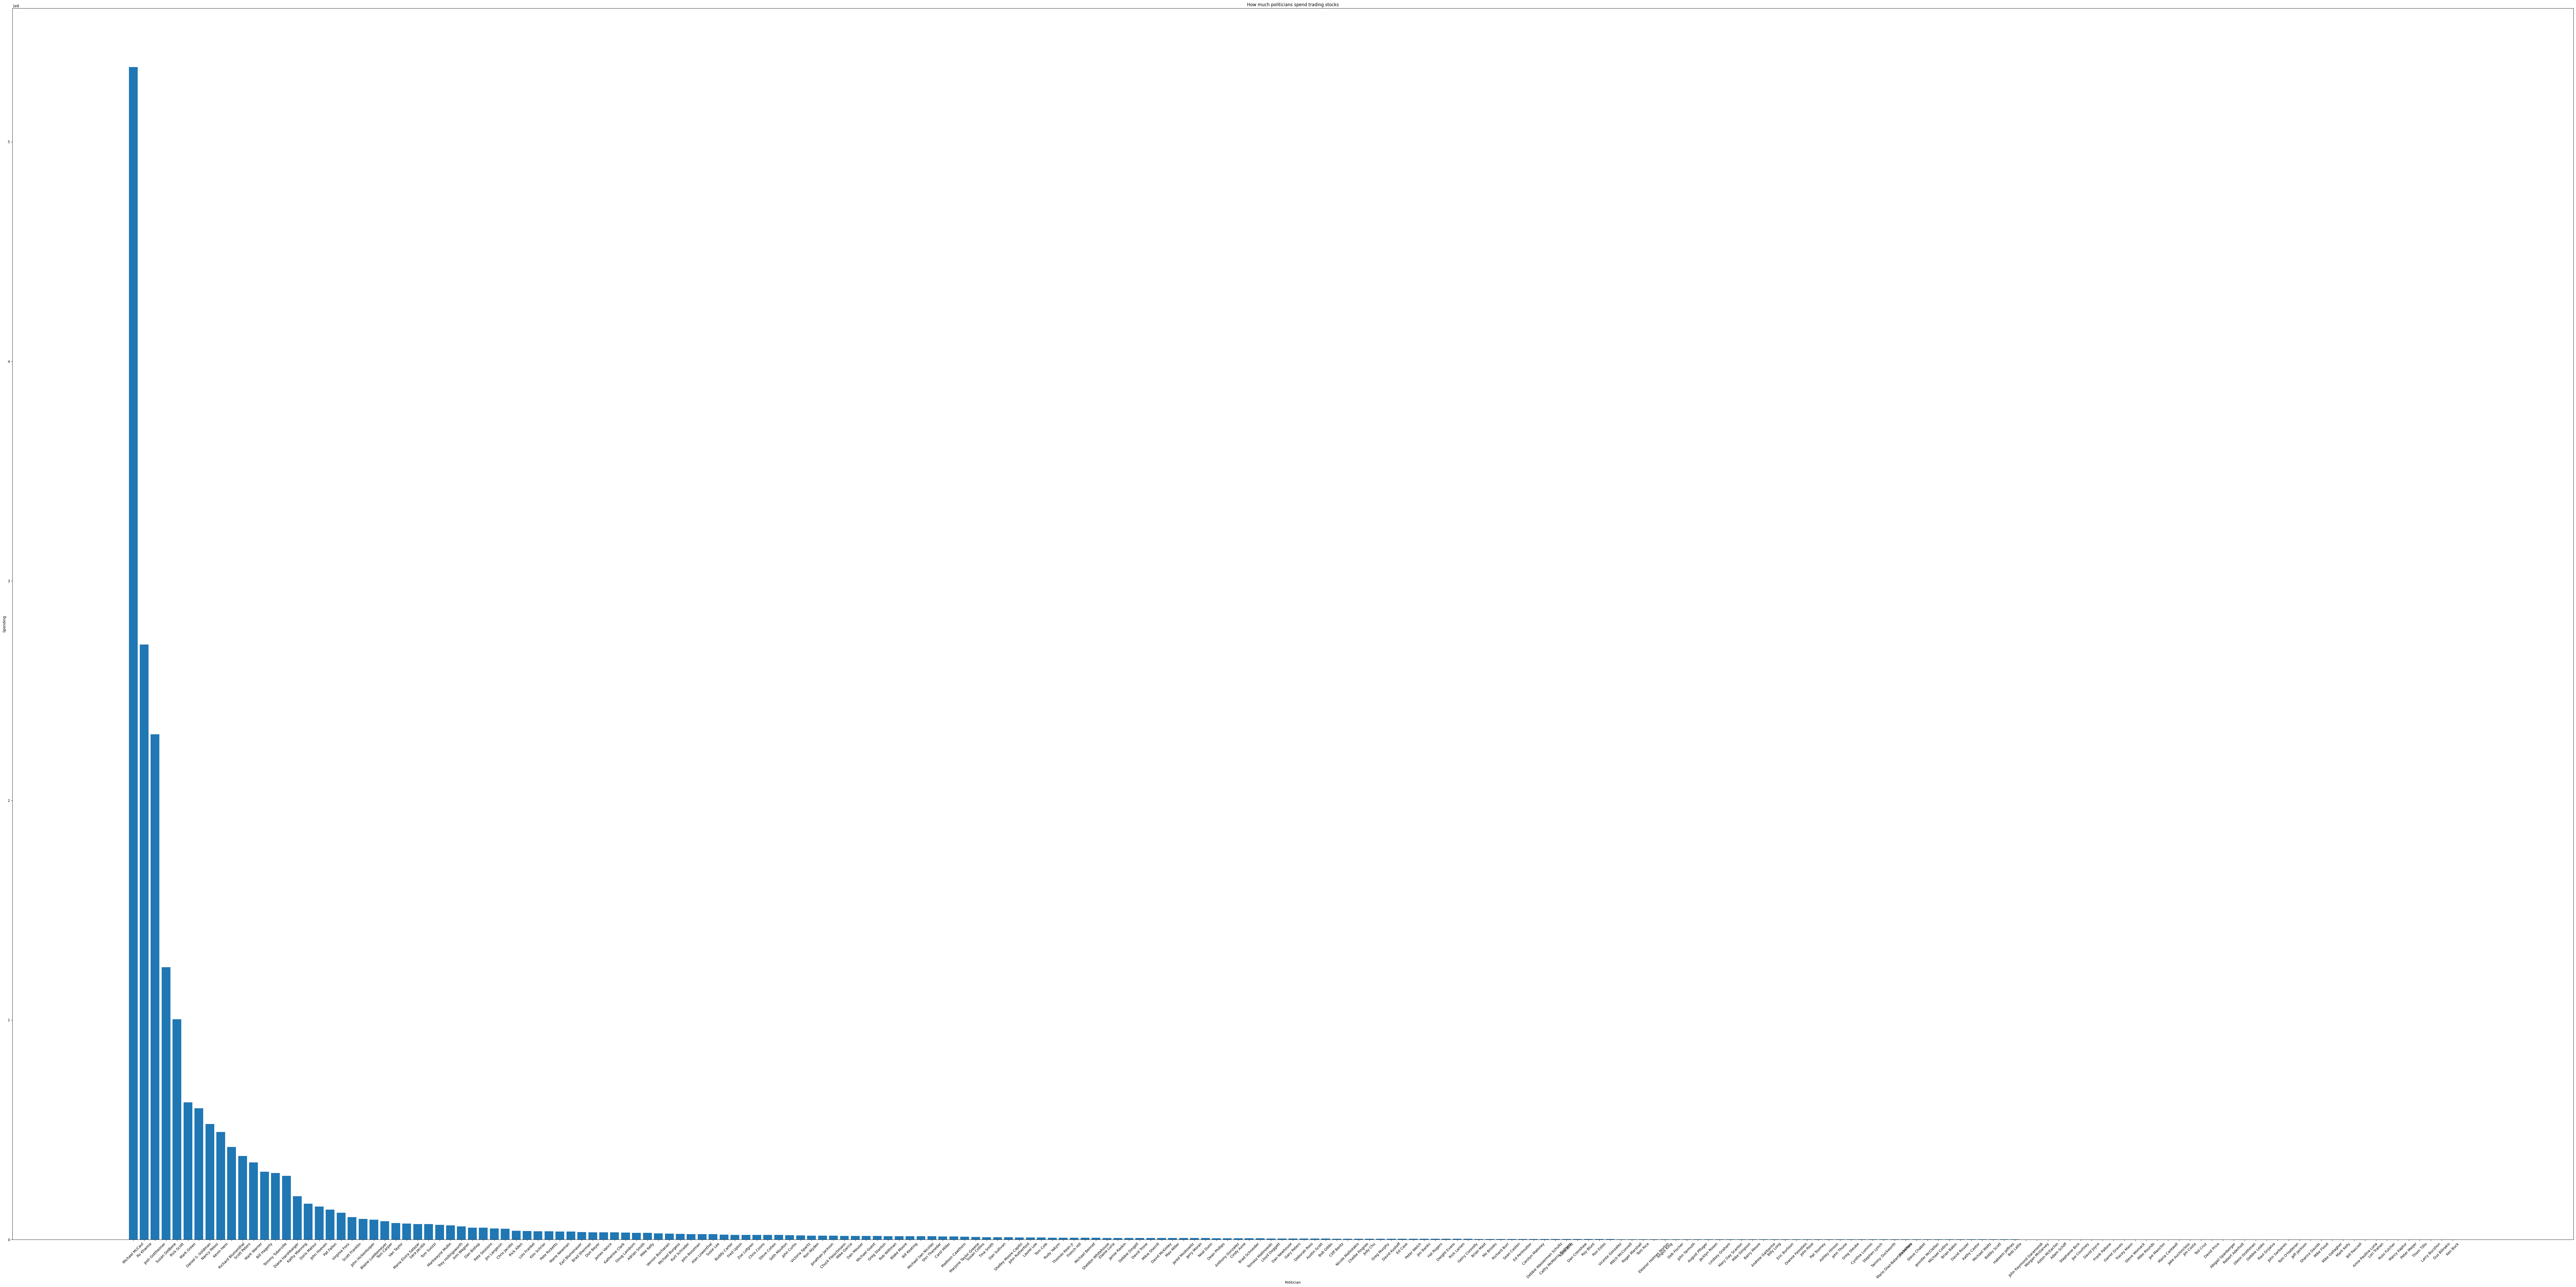

In [137]:
# Chart this
plt.figure(figsize=(100, 50))  # Adjust size as needed
full_name = indiv_spend_df["politician_full_name"] 
value = indiv_spend_df["value_avg"]

plt.bar(full_name, value )

# Adding labels and title
plt.xlabel('Politician')
plt.ylabel('Spending')
plt.title('How much politicians spend trading stocks')

# Rotating x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()  # Adjust layout
plt.show()

In [138]:
print_spend_totals(indiv_spend_df)

indiv_spend_df.describe()

low total 9.892229e+08
high total 3.029912e+09
avg total 2.009586e+09


,value_low,value_high,value_avg
count,2.130000e+02,2.130000e+02,2.130000e+02
mean,4.644239e+06,1.422494e+07,9.434678e+06
std,2.434443e+07,6.736433e+07,4.557162e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,3.000200e+04,1.300000e+05,8.100400e+04
50%,1.920240e+05,8.000000e+05,4.870280e+05
75%,1.109220e+06,4.000000e+06,2.422269e+06
max,3.160834e+08,7.520950e+08,5.340919e+08


In [139]:
buy_master_df = master_df[master_df["tx_type"] == "BUY"]
indiv_buy_df = get_spend_df(buy_master_df)

print_spend_totals(indiv_buy_df)
indiv_buy_df.describe()

indiv_buy_df

low total 4.932465e+08
high total 1.492669e+09
avg total 9.929675e+08


,politician_id,politician_full_name,value_low,value_high,value_avg
0,M001157,Michael McCaul,132848379,310940000,221895379
1,K000389,Ro Khanna,63987599,256910000,160453099
2,G000583,Josh Gottheimer,40240595,183800000,112020595
3,D000617,Suzan DelBene,29682137,106005000,67843637
4,S001217,Rick Scott,26450084,54000000,40225084
...,...,...,...,...,...
161,R000603,David Rouzer,1001,15000,8001
162,A000055,Robert Aderholt,1001,15000,8001
163,L000576,Billy Long,1001,15000,8001
164,B000668,Cliff Bentz,1001,15000,8001


In [140]:
sell_master_df = master_df[master_df["tx_type"] == "SELL"]
indiv_sell_df = get_spend_df(sell_master_df)

indiv_sell_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,M001157,Michael McCaul,183235022,441155000,312196522
1,G000583,Josh Gottheimer,42643752,193645000,118144752
2,K000389,Ro Khanna,42625497,178485000,110558497
3,S001217,Rick Scott,23903037,96245000,60074037
4,D000617,Suzan DelBene,26190061,85775000,55982561
...,...,...,...,...,...
176,B001257,Gus Bilirakis,1001,15000,8001
177,A000055,Robert Aderholt,1001,15000,8001
178,M001186,Peter Meijer,1001,15000,8001
179,G000551,Raul Grijalva,1001,15000,8001


In [141]:
print_spend_totals(indiv_sell_df)
indiv_sell_df.describe()

low total 4.887413e+08
high total 1.520592e+09
avg total 1.004676e+09


,value_low,value_high,value_avg
count,1.810000e+02,1.810000e+02,1.810000e+02
mean,2.700228e+06,8.401061e+06,5.550695e+06
std,1.466311e+07,3.944924e+07,2.691505e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,1.900500e+04,1.050000e+05,6.500200e+04
50%,1.200220e+05,5.000000e+05,3.250030e+05
75%,6.630730e+05,2.320000e+06,1.508661e+06
max,1.832350e+08,4.411550e+08,3.121965e+08


In [142]:
"""
Spending house vs senate
"""
house_master_df = master_df[master_df["politician_chamber"] == "House"]
house_spend_df = get_spend_df(house_master_df)

house_spend_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,M001157,Michael McCaul,316083401,752095000,534091901
1,K000389,Ro Khanna,106613096,435395000,271011596
2,G000583,Josh Gottheimer,82886349,377475000,230181349
3,D000617,Suzan DelBene,55972199,192030000,124001199
4,G000590,Mark Green,37141240,87765000,62453240
...,...,...,...,...,...
165,B001275,Larry Bucshon,1001,15000,8001
166,P000096,Bill Pascrell,1001,15000,8001
167,M001186,Peter Meijer,1001,15000,8001
168,G000579,Mike Gallagher,1001,15000,8001


In [143]:
print_spend_totals(house_spend_df)
house_spend_df.describe()

low total 8.379957e+08
high total 2.578527e+09
avg total 1.708279e+09


,value_low,value_high,value_avg
count,1.700000e+02,1.700000e+02,1.700000e+02
mean,4.929386e+06,1.516781e+07,1.004870e+07
std,2.686888e+07,7.425380e+07,5.024489e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,2.250850e+04,1.250000e+05,7.500100e+04
50%,2.100050e+05,8.150000e+05,4.870425e+05
75%,1.018008e+06,3.820000e+06,2.250760e+06
max,3.160834e+08,7.520950e+08,5.340919e+08


In [144]:
senate_master_df = master_df[master_df["politician_chamber"] == "Senate"]
senate_spend_df = get_spend_df(senate_master_df)

senate_spend_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,S001217,Rick Scott,50353121,150245000,100299121
1,B001277,Richard Blumenthal,26798270,57570000,42184270
2,W000805,Mark Warner,20115067,50200000,35157567
3,H000601,Bill Hagerty,11336044,50490000,30913044
4,T000278,Tommy Tuberville,14839082,45720000,30280082
5,H001061,John Hoeven,5000001,25000000,15000001
6,H000273,John Hickenlooper,5793080,12970000,9381580
7,C000174,Tom Carper,2943547,13645000,8294547
8,M001190,Markwayne Mullin,3574189,9910000,6742189
9,R000618,Pete Ricketts,2250030,5250000,3750030


In [145]:
print_spend_totals(senate_spend_df)
senate_spend_df.describe()

low total 1.512272e+08
high total 4.513850e+08
avg total 3.013077e+08


,value_low,value_high,value_avg
count,4.300000e+01,4.300000e+01,4.300000e+01
mean,3.516912e+06,1.049733e+07,7.007156e+06
std,9.214667e+06,2.649998e+07,1.780151e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,5.250700e+04,1.950000e+05,1.227535e+05
50%,1.660050e+05,7.850000e+05,4.870280e+05
75%,1.251506e+06,4.775000e+06,2.853862e+06
max,5.035312e+07,1.502450e+08,1.002991e+08


In [146]:
"""
Spending dem vs rep
"""
dem_master_df = master_df[master_df["politician_party"] == "Democrat"]
dem_spend_df = get_spend_df(dem_master_df)

dem_spend_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,K000389,Ro Khanna,106613096,435395000,271011596
1,G000583,Josh Gottheimer,82886349,377475000,230181349
2,D000617,Suzan DelBene,55972199,192030000,124001199
3,G000599,Daniel S. Goldman,32099306,87420000,59760306
4,P000197,Nancy Pelosi,24945060,80302997,52624060
...,...,...,...,...,...
91,D000629,Sharice Davids,1001,19995,10501
92,T000482,Lori Trahan,1001,15000,8001
93,P000096,Bill Pascrell,1001,15000,8001
94,K000009,Marcy Kaptur,1001,15000,8001


In [147]:
print_spend_totals(dem_spend_df)
dem_spend_df.describe()

low total 4.430175e+08
high total 1.542549e+09
avg total 9.927950e+08


,value_low,value_high,value_avg
count,9.600000e+01,9.600000e+01,9.600000e+01
mean,4.614765e+06,1.606822e+07,1.034161e+07
std,1.557829e+07,6.232668e+07,3.885705e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,1.875825e+04,1.182492e+05,7.425300e+04
50%,2.150030e+05,8.400000e+05,5.387920e+05
75%,1.058827e+06,4.207249e+06,2.431121e+06
max,1.066131e+08,4.353950e+08,2.710116e+08


In [148]:
rep_master_df = master_df[master_df["politician_party"] == "Republican"]
rep_spend_df = get_spend_df(rep_master_df)

rep_spend_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,M001157,Michael McCaul,316083401,752095000,534091901
1,S001217,Rick Scott,50353121,150245000,100299121
2,G000590,Mark Green,37141240,87765000,62453240
3,H001082,Kevin Hern,25365500,72525000,48945500
4,H000601,Bill Hagerty,11336044,50490000,30913044
...,...,...,...,...,...
111,B001275,Larry Bucshon,1001,15000,8001
112,F000474,Mike Flood,1001,15000,8001
113,F000469,Russ Fulcher,1001,15000,8001
114,G000579,Mike Gallagher,1001,15000,8001


In [149]:
print_spend_totals(rep_spend_df)
rep_spend_df.describe()

low total 5.461514e+08
high total 1.487078e+09
avg total 1.016622e+09


,value_low,value_high,value_avg
count,1.160000e+02,1.160000e+02,1.160000e+02
mean,4.708202e+06,1.281964e+07,8.763982e+06
std,2.986426e+07,7.176398e+07,5.078695e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,3.576825e+04,1.537500e+05,1.027582e+05
50%,1.550115e+05,7.700000e+05,4.427885e+05
75%,1.139591e+06,3.696250e+06,2.326314e+06
max,3.160834e+08,7.520950e+08,5.340919e+08


In [150]:
states_spend_df = get_spend_df_states(master_df)
states_spend_df

,politician_state,value_low,value_high,value_avg
0,Texas,331209950,797924985,564570450
1,California,175600772,615378996,395497772
2,New Jersey,83978410,380730000,232354910
3,Washington,58707333,199280000,128993833
4,Florida,63042056,194265999,128654556
5,Tennessee,56987383,196485000,126737883
6,New York,38477748,106515999,72497748
7,Oklahoma,29517698,83730000,56624198
8,Connecticut,26864273,57735000,42299773
9,Virginia,22141503,60366998,41254503


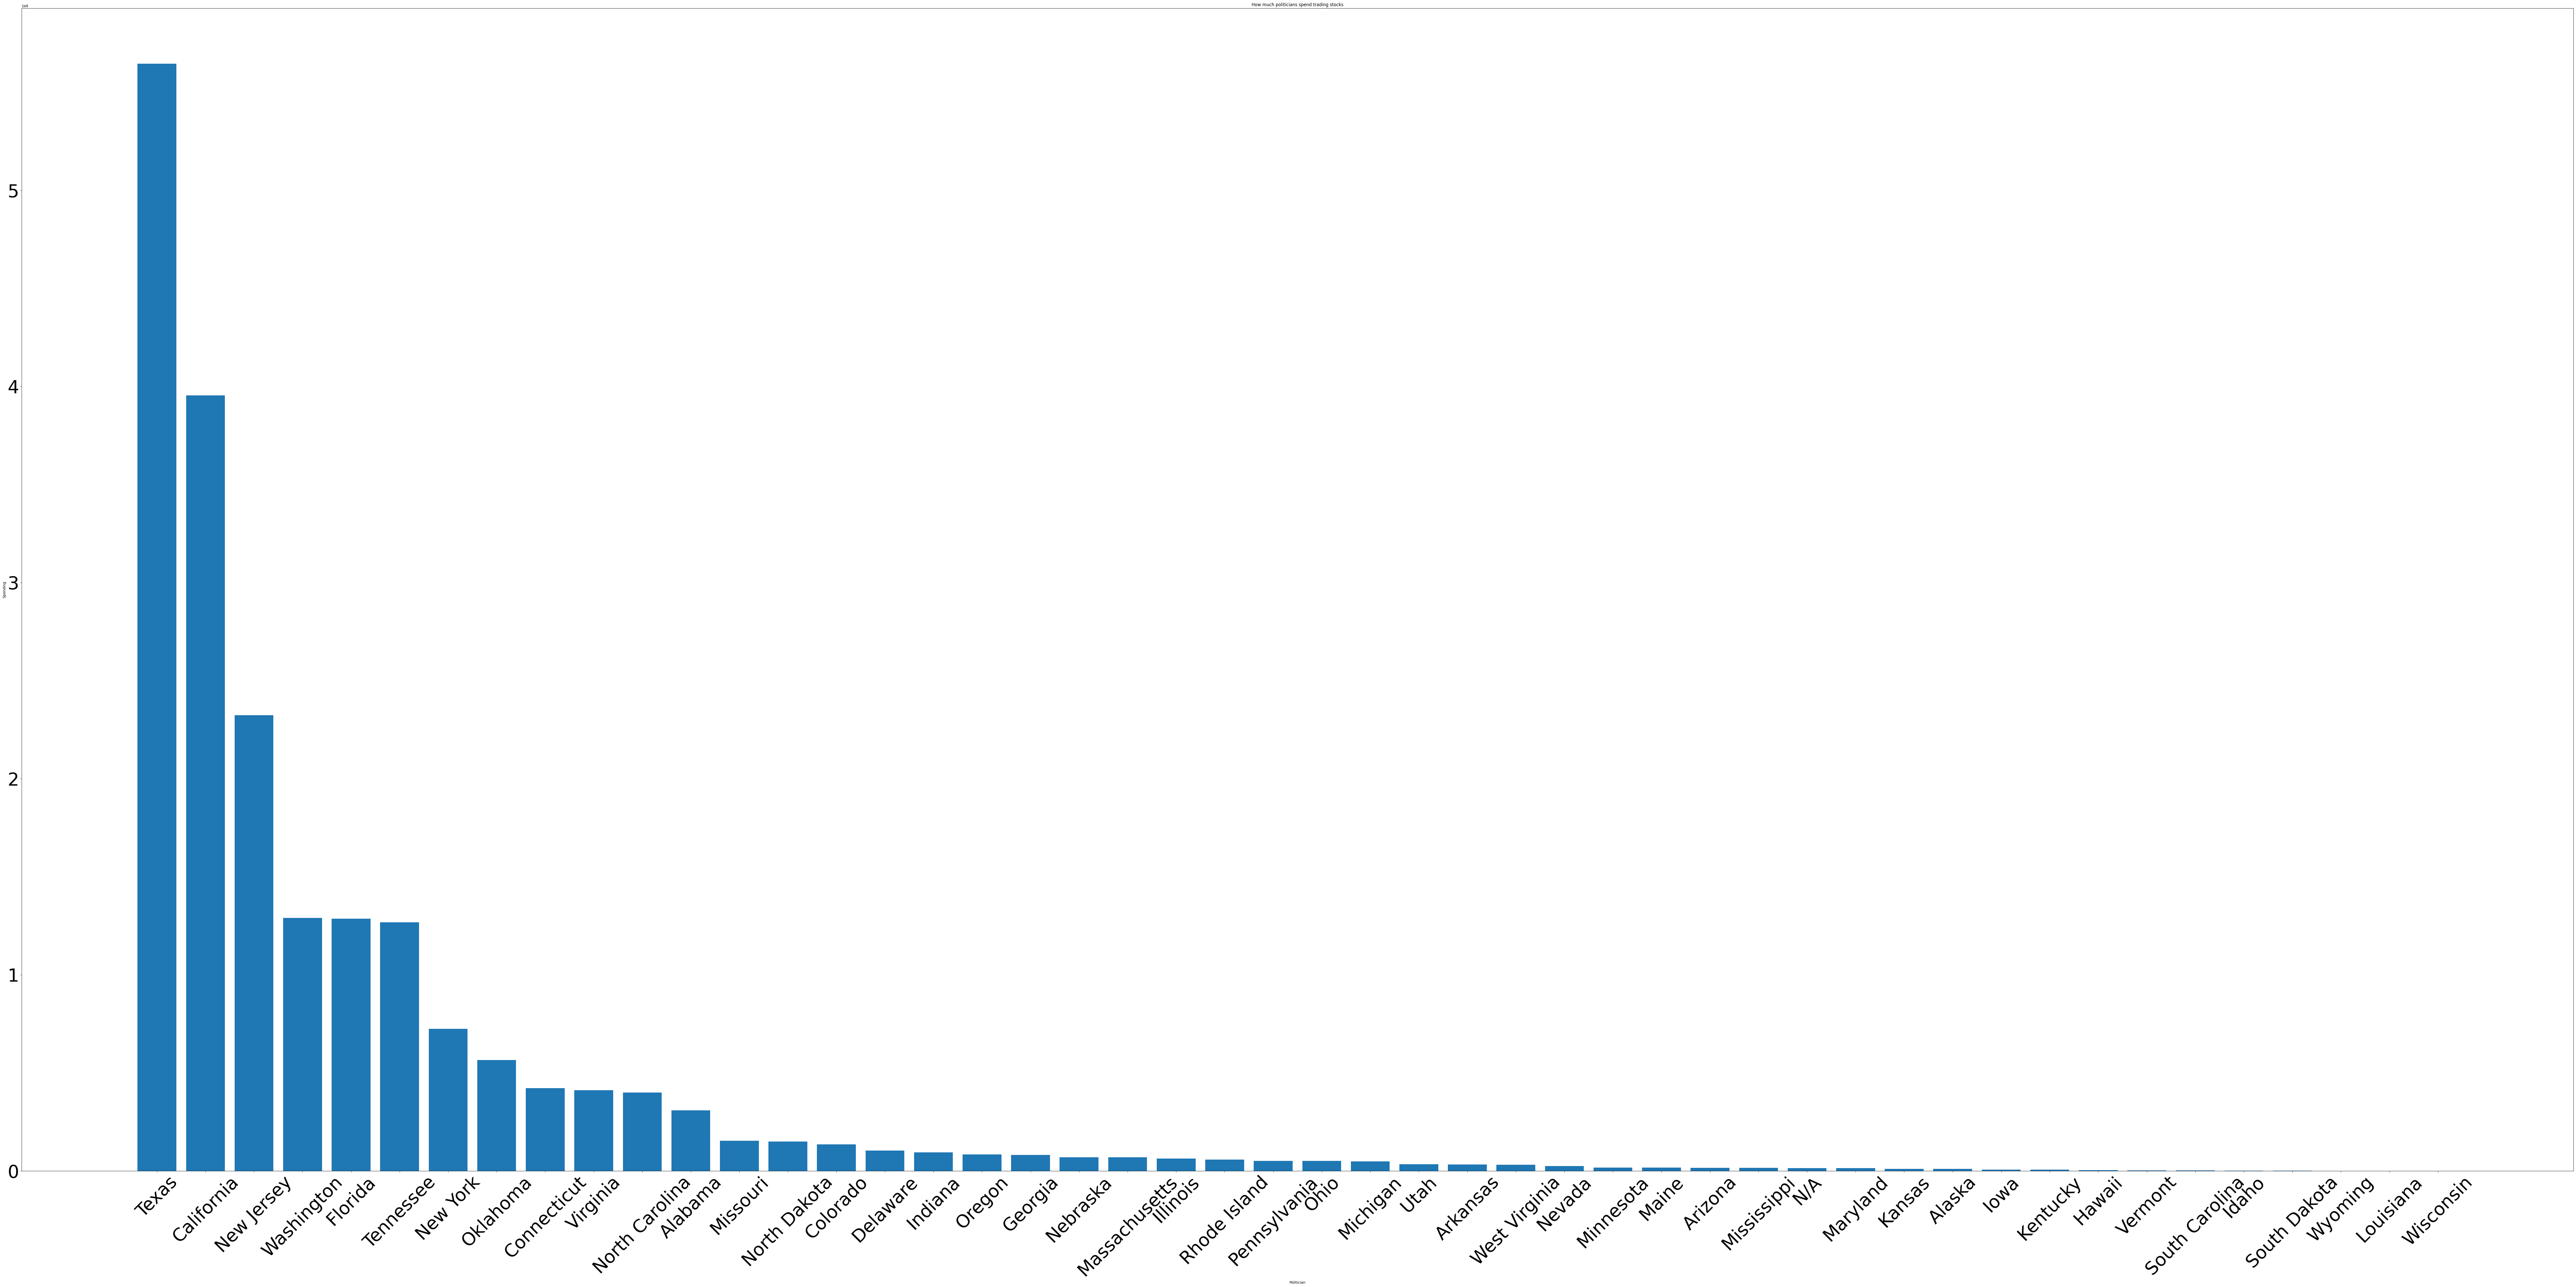

In [151]:
# Chart this
plt.figure(figsize=(100, 50))  # Adjust size as needed
state_name = states_spend_df["politician_state"] 
value = states_spend_df["value_avg"]

plt.bar(state_name, value )

# Adding labels and title
plt.xlabel('Politician')
plt.ylabel('Spending')
plt.title('How much politicians spend trading stocks')

# Rotating x-axis labels for better readability (optional)
plt.xticks(rotation=45,  fontsize=50)
plt.yticks(  fontsize=50)

# Show plot
plt.tight_layout()  # Adjust layout
plt.show()

In [152]:
"""
 Trade frequencies
"""
frequency_df = master_df.copy(deep=True)
frequency_df['count_trades'] = frequency_df.groupby('politician_id')['politician_id'].transform('count')
frequency_df = frequency_df[["politician_id","politician_full_name", "politician_chamber", "politician_party", "count_trades"]]
frequency_df = frequency_df.drop_duplicates(subset="politician_id")
frequency_df = frequency_df.sort_values(by="count_trades", ascending=False)
frequency_df = frequency_df.reset_index(drop=True)
frequency_df

,politician_id,politician_full_name,politician_chamber,politician_party,count_trades
0,K000389,Ro Khanna,House,Democrat,15096
1,M001157,Michael McCaul,House,Republican,5401
2,H001086,Diana Harshbarger,House,Republican,2899
3,G000583,Josh Gottheimer,House,Democrat,1349
4,G000599,Daniel S. Goldman,House,Democrat,1306
...,...,...,...,...,...
208,B001257,Gus Bilirakis,House,Republican,1
209,M001210,Greg Murphy,House,Republican,1
210,T000482,Lori Trahan,House,Democrat,1
211,F000474,Mike Flood,House,Republican,1


In [153]:
sum_count_trades = frequency_df["count_trades"].sum()
print("Total trades", sum_count_trades)

frequency_df.describe()

Total trades 37914


,count_trades
count,213.000000
mean,178.000000
std,1120.042936
min,1.000000
25%,3.000000
50%,12.000000
75%,61.000000
max,15096.000000


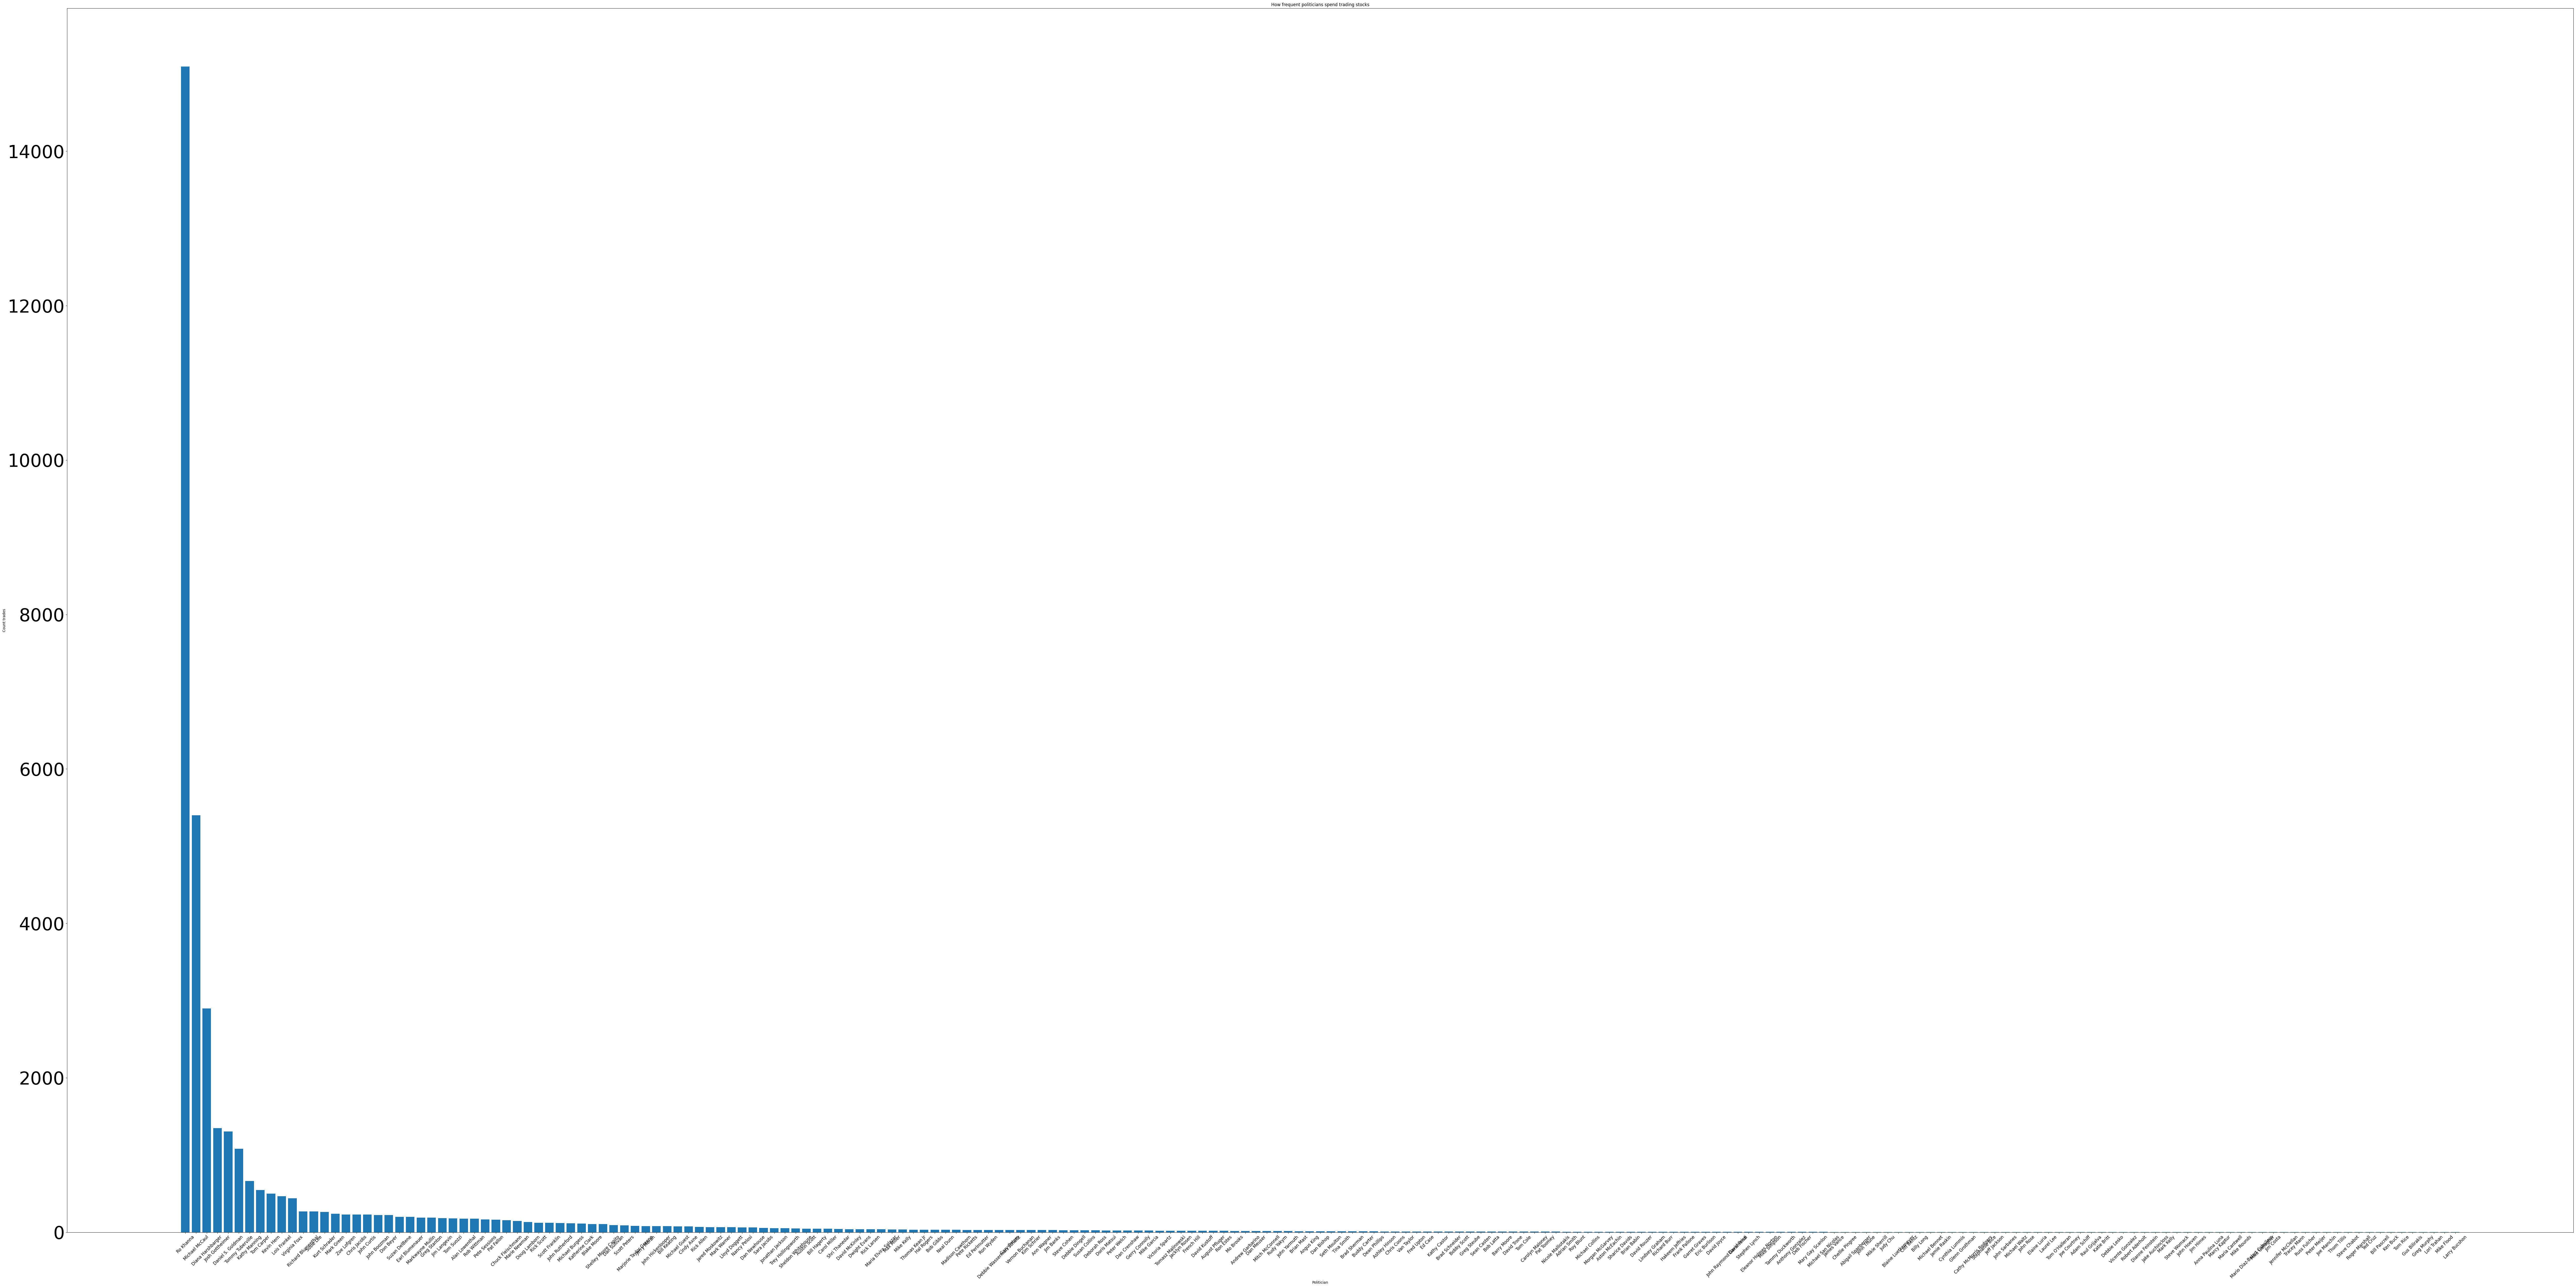

In [154]:
# Chart this
plt.figure(figsize=(100, 50))  # Adjust size as needed
x_axis = frequency_df["politician_full_name"] 
y_axis = frequency_df["count_trades"]

plt.bar( x_axis, y_axis )

# Adding labels and title
plt.xlabel('Politician')
plt.ylabel('Count trades')
plt.title('How frequent politicians spend trading stocks')

# Rotating x-axis labels for better readability (optional)
plt.xticks(rotation=45,  fontsize=12)
plt.yticks( fontsize=50)

# Show plot
plt.tight_layout()  # Adjust layout
plt.show()

In [155]:
"""
Time frequency
"""
time_frequency_df = master_df.copy(deep=True)
time_frequency_df['count_trades'] = time_frequency_df.groupby('tx_date')['tx_date'].transform('count')
time_frequency_df = time_frequency_df[["tx_date", "count_trades"]]
time_frequency_df = time_frequency_df.drop_duplicates(subset="tx_date")
time_frequency_df = time_frequency_df.sort_values(by="tx_date").reset_index(drop=True)
time_frequency_df


,tx_date,count_trades
0,2021-03-23,29
1,2021-03-24,36
2,2021-03-25,26
3,2021-03-26,29
4,2021-03-29,59
...,...,...
806,2024-03-05,3
807,2024-03-07,6
808,2024-03-08,1
809,2024-03-11,1


In [156]:
time_frequency_df.describe()

,tx_date,count_trades
count,811,811.000000
mean,2022-09-12 13:34:59.630086400,46.749692
min,2021-03-23 00:00:00,1.000000
25%,2021-12-18 12:00:00,17.000000
50%,2022-09-08 00:00:00,29.000000
75%,2023-06-12 12:00:00,49.000000
max,2024-03-18 00:00:00,423.000000
std,NaN,60.532781


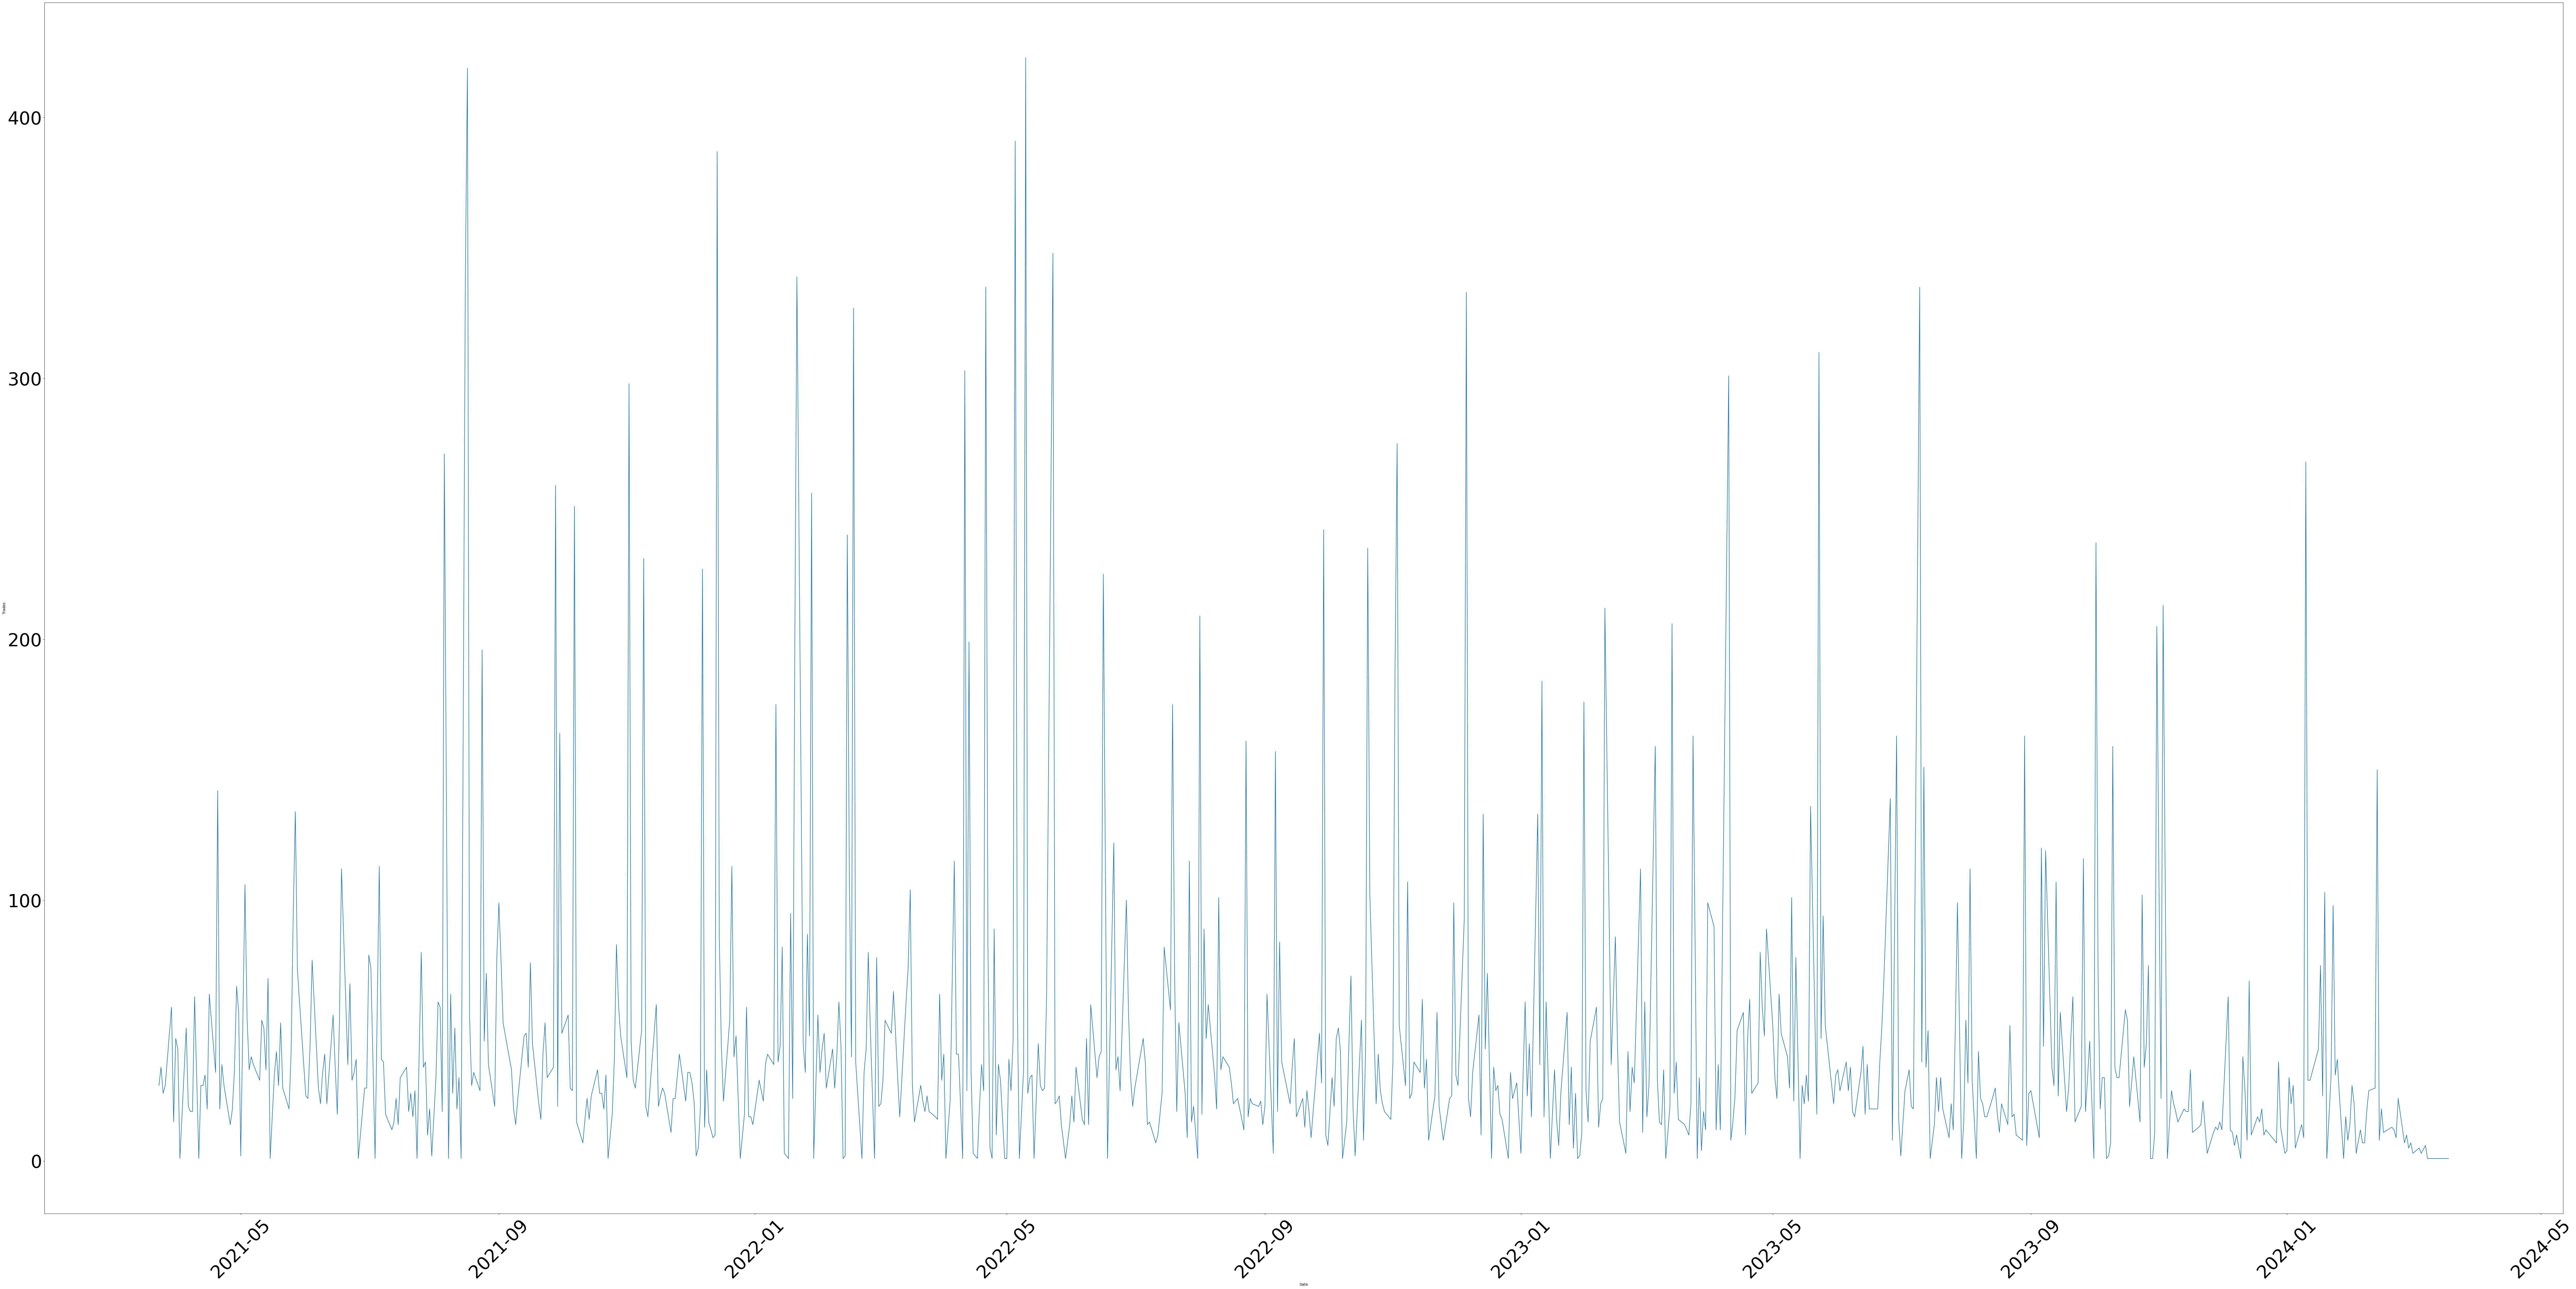

In [157]:
# Chart this
plt.figure(figsize=(100, 50))  # Adjust size as needed
x_axis = time_frequency_df["tx_date"] 
y_axis = time_frequency_df["count_trades"]

plt.plot(x_axis, y_axis )

# Adding labels and title
plt.xlabel('Date')
plt.ylabel('Trades')

# Rotating x-axis labels for better readability (optional)
plt.xticks(rotation=45,  fontsize=50)
plt.yticks(  fontsize=50)

# Show plot
plt.tight_layout()  # Adjust layout
plt.show()

In [158]:
interest_time_df = time_frequency_df[time_frequency_df["count_trades"] > 150]
interest_time_df

,tx_date,count_trades
103,2021-08-06,271
111,2021-08-16,337
112,2021-08-17,419
117,2021-08-24,196
141,2021-09-28,259
143,2021-09-30,164
148,2021-10-07,251
167,2021-11-02,298
172,2021-11-09,231
193,2021-12-07,227


In [159]:
interest_trades_df = master_df[master_df["tx_date"].isin(interest_time_df["tx_date"])]
interest_trades_df

,politician_id,issuer_name,ticker,issuer_id,published_date,tx_date,reporting_gap,owner,tx_type,value,...,politician_issuers,politician_volume,politician_last_traded,politician_district,politician_years_active,politician_date_of_birth,politician_age,politician_committee_list,politician_year_active_started,politician_year_active_ended
126,K000389,Bank of America Corp,BAC,429988,2024-02-07,2024-01-10,26,Child,BUY,15K-50K,...,1190,272060000,2024-02-29,17,2017 - 2025,1976-09-13,47,"[Armed Services, Oversight and Reform, Strateg...",2017,2025
127,K000389,Visa Inc,V,435735,2024-02-07,2024-01-10,26,Child,BUY,15K-50K,...,1190,272060000,2024-02-29,17,2017 - 2025,1976-09-13,47,"[Armed Services, Oversight and Reform, Strateg...",2017,2025
128,K000389,Uber Technologies Inc,UBER,435432,2024-02-07,2024-01-10,26,Child,BUY,15K-50K,...,1190,272060000,2024-02-29,17,2017 - 2025,1976-09-13,47,"[Armed Services, Oversight and Reform, Strateg...",2017,2025
129,K000389,The Coca-Cola Co,KO,430852,2024-02-07,2024-01-10,26,Child,BUY,15K-50K,...,1190,272060000,2024-02-29,17,2017 - 2025,1976-09-13,47,"[Armed Services, Oversight and Reform, Strateg...",2017,2025
130,K000389,Bristol-Myers Squibb Co,BMY,430231,2024-02-07,2024-01-10,26,Child,BUY,15K-50K,...,1190,272060000,2024-02-29,17,2017 - 2025,1976-09-13,47,"[Armed Services, Oversight and Reform, Strateg...",2017,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34740,H001086,Chegg Inc,CHGG,430502,2021-08-28,2021-08-16,11,Undisclosed,BUY,1K-15K,...,271,29070000,2023-02-22,1,2021 - 2025,1960-01-01,64,[Energy & Commerce],2021,2025
34741,H001086,Chegg Inc,CHGG,430502,2021-08-28,2021-08-16,11,Joint,BUY,1K-15K,...,271,29070000,2023-02-22,1,2021 - 2025,1960-01-01,64,[Energy & Commerce],2021,2025
34742,H001086,Chegg Inc,CHGG,430502,2021-08-28,2021-08-16,11,Spouse,BUY,1K-15K,...,271,29070000,2023-02-22,1,2021 - 2025,1960-01-01,64,[Energy & Commerce],2021,2025
35578,B000740,Wells Fargo & Co,WFC,1282836,2021-08-13,2021-08-06,6,Joint,SELL,1K-15K,...,2,41000,2022-12-12,5,2021 - 2025,1973-11-11,50,"[Appropriations, Budget, House Administration,...",2021,2025


In [160]:
"""
Non ticker trades
"""
non_ticker_trades_df = master_df[master_df["ticker"].isna()].reset_index(drop=True)
non_ticker_trades_df

,politician_id,issuer_name,ticker,issuer_id,published_date,tx_date,reporting_gap,owner,tx_type,value,...,politician_issuers,politician_volume,politician_last_traded,politician_district,politician_years_active,politician_date_of_birth,politician_age,politician_committee_list,politician_year_active_started,politician_year_active_ended
0,M001204,US TREASURY BILLS,None,435544,2024-03-22,2024-02-23,27,Spouse,BUY,250K-500K,...,3,1650000,2024-02-23,9,2019 - 2025,1964-02-10,60,"[Financial Services, Small business]",2019,2025
1,P000197,FORGE INVESTMENTS LLC,None,2334676,2024-03-22,2024-03-04,17,Spouse,BUY,1M-5M,...,22,51740000,2024-02-21,11,1987 - 2025,1940-03-26,83,[],1987,2025
2,M001222,ELLIOTT ASSOCIATES LP,None,2334424,2024-03-19,2024-03-18,0,Undisclosed,BUY,15K-50K,...,21,684000,2024-03-18,7,2023 - 2025,1988-11-13,35,"[Agriculture, Science, Space and Technology]",2023,2025
3,S001217,PORT AUTHORITY OF NEW YORK AND NEW JERSEY,None,434130,2024-03-15,2024-03-05,10,Self,SELL,500K-1M,...,45,100300000,2024-03-05,NaN,2019 - 2025,1952-12-01,71,"[Aging, Armed Services, Budget, Homeland Secur...",2019,2025
4,S001217,NEW YORK STATE URBAN DEVELOPMENT CORP,None,433642,2024-03-15,2024-03-05,10,Self,SELL,500K-1M,...,45,100300000,2024-03-05,NaN,2019 - 2025,1952-12-01,71,"[Aging, Armed Services, Budget, Homeland Secur...",2019,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,M001157,RECURRING CAPITAL FUND II LP,None,434335,2021-04-20,2021-03-31,19,Child,BUY,15K-50K,...,532,570120000,2024-01-31,10,2005 - 2025,1962-01-14,62,"[Foreign Affairs, Homeland Security]",2005,2025
3897,D000617,LOS ANGELES COUNTY TREASURER AND TAX COLLECTOR,None,433111,2021-04-14,2021-03-31,13,Joint,SELL,15K-50K,...,52,124000000,2024-02-29,1,2012 - 2025,1962-02-17,62,[Ways & Means],2012,2025
3898,D000617,CITY OF NEW YORK,None,430715,2021-04-14,2021-03-25,19,Joint,BUY,15K-50K,...,52,124000000,2024-02-29,1,2012 - 2025,1962-02-17,62,[Ways & Means],2012,2025
3899,W000805,REVIVAL LOC LLC,None,434380,2021-04-13,2021-03-29,14,Self,SELL,1M-5M,...,45,35160000,2024-01-11,NaN,2009 - 2025,1954-12-15,69,"[Intelligence, Banking, Housing & Urban Affair...",2009,2025


In [161]:
# Data on people who spent on stuff without tickers
non_ticker_spend_df = get_spend_df(non_ticker_trades_df)
non_ticker_spend_df

,politician_id,politician_full_name,value_low,value_high,value_avg
0,M001157,Michael McCaul,142282274,330015000,236149274
1,S001217,Rick Scott,48350115,143200000,95775115
2,D000617,Suzan DelBene,33020185,83000000,58010185
3,K000389,Ro Khanna,24263654,67070000,45667154
4,P000608,Scott Peters,25045089,51200000,38122589
...,...,...,...,...,...
106,N000189,Dan Newhouse,1001,15000,8001
107,K000377,Mark Kelly,1001,15000,8001
108,P000523,David Price,1001,15000,8001
109,F000474,Mike Flood,1001,15000,8001


In [162]:
print_spend_totals(non_ticker_spend_df)
non_ticker_spend_df.describe()

low total 4.220769e+08
high total 1.079975e+09
avg total 7.510279e+08


,value_low,value_high,value_avg
count,1.110000e+02,1.110000e+02,1.110000e+02
mean,3.802495e+06,9.729504e+06,6.766017e+06
std,1.501042e+07,3.607615e+07,2.550994e+07
min,1.001000e+03,1.500000e+04,8.001000e+03
25%,1.500100e+04,7.500000e+04,4.000500e+04
50%,2.000020e+05,5.000000e+05,3.500020e+05
75%,1.401510e+06,3.860000e+06,2.732038e+06
max,1.422823e+08,3.300150e+08,2.361493e+08


In [163]:
ticker_locations_df = master_df.copy(deep=True)
ticker_locations_df = ticker_locations_df[~ticker_locations_df["ticker"].isna()]
ticker_locations_df['count_trades'] = ticker_locations_df.groupby('ticker_location')['ticker_location'].transform('count')
ticker_locations_df = ticker_locations_df[["ticker_location", "count_trades"]]
ticker_locations_df = ticker_locations_df.drop_duplicates(subset="ticker_location")
ticker_locations_df = ticker_locations_df.sort_values(by="count_trades").reset_index(drop=True)
ticker_locations_df

,ticker_location,count_trades
0,UC,1.0
1,FH,1.0
2,NZ,1.0
3,UD,1.0
4,JP,2.0
5,SS,3.0
6,BB,3.0
7,CN,4.0
8,LN,4.0
9,BZ,7.0


In [164]:
non_us_trades_df = master_df[(~master_df["ticker"].isna()) & (master_df["ticker_location"] != "US")].copy(deep=True).reset_index(drop=True)
non_us_trades_df = non_us_trades_df[["politician_id", "issuer_name", "politician_full_name", "ticker", "ticker_location", "tx_date", "value_low", "value_high", "value_avg"]]
non_us_trades_df

,politician_id,issuer_name,politician_full_name,ticker,ticker_location,tx_date,value_low,value_high,value_avg
0,K000389,TransCanada PipeLines Ltd,Ro Khanna,559242Z,CN,2023-04-20,1001,15000,8001
1,K000389,TransCanada PipeLines Ltd,Ro Khanna,559242Z,CN,2023-04-28,1001,15000,8001
2,G000599,Electrolux AB,Daniel S. Goldman,ELUXB,SS,2023-02-27,1001,15000,8001
3,G000599,Japan Airlines Co Ltd,Daniel S. Goldman,9201,JP,2023-01-13,1001,15000,8001
4,J000308,ANKR,Jeff Jackson,$ANKR,None,2023-01-29,1001,15000,8001
...,...,...,...,...,...,...,...,...,...
97,G000590,DOGECOIN,Mark Green,$DOGE,None,2021-04-01,1001,15000,8001
98,G000590,DOGECOIN,Mark Green,$DOGE,None,2021-04-14,1001,15000,8001
99,G000590,EOS,Mark Green,$EOS,None,2021-04-13,1001,15000,8001
100,G000590,ETHEREUM CLASSIC,Mark Green,$ETC,None,2021-04-13,1001,15000,8001


In [165]:
# Crypto
non_us_trades_df[non_us_trades_df["ticker"].str.startswith("$")]

,politician_id,issuer_name,politician_full_name,ticker,ticker_location,tx_date,value_low,value_high,value_avg
4,J000308,ANKR,Jeff Jackson,$ANKR,None,2023-01-29,1001,15000,8001
5,J000308,CARDANO,Jeff Jackson,$ADA,None,2023-01-29,1001,15000,8001
7,C001104,LET'S GO BRANDON,Madison Cawthorn,$LGB,None,2022-01-17,15001,50000,32501
8,C001129,ETHEREUM,Michael Collins,$ETH,None,2024-01-03,1001,15000,8001
9,C001129,ETHEREUM,Michael Collins,$ETH,None,2024-01-08,15001,50000,32501
...,...,...,...,...,...,...,...,...,...
97,G000590,DOGECOIN,Mark Green,$DOGE,None,2021-04-01,1001,15000,8001
98,G000590,DOGECOIN,Mark Green,$DOGE,None,2021-04-14,1001,15000,8001
99,G000590,EOS,Mark Green,$EOS,None,2021-04-13,1001,15000,8001
100,G000590,ETHEREUM CLASSIC,Mark Green,$ETC,None,2021-04-13,1001,15000,8001


In [166]:
non_us_trades_df["issuer_name"].value_counts()

issuer_name
ETHEREUM                              15
CSPC Pharmaceutical Group Ltd         11
BITCOIN                               10
BR PROPERTIES SA                       7
SOLANA                                 6
CARDANO                                5
TransCanada PipeLines Ltd              4
DOGECOIN                               4
KRYLL                                  4
LET'S GO BRANDON                       4
ETHEREUM CLASSIC                       3
REQUEST                                3
VGP N.V.                               3
CHAINLINK                              2
3I GROUP PLC                           2
STELLAR LUMENS                         2
McDonald's Holdings Co (Japan) Ltd     1
CELO                                   1
BASIC ATTENTION TOKEN                  1
AMERICAN FUNDS NEW WORLD FUND          1
ARBORGEN HOLDINGS LTD                  1
LITECOIN                               1
BRITVIC PLC                            1
Vaisala OYJ                            1
Swed

In [167]:
non_us_trades_df.groupby("issuer_name")["value_avg"].sum().reset_index()

,issuer_name,value_avg
0,3I GROUP PLC,16002
1,AMERICAN FUNDS NEW WORLD FUND,8001
2,ANKR,8001
3,ARBORGEN HOLDINGS LTD,8001
4,Anta Sports Products,8001
5,BASIC ATTENTION TOKEN,8001
6,BITCOIN,661010
7,BR PROPERTIES SA,129507
8,BRITVIC PLC,8001
9,Barclays Bank PLC,375001
